In [1]:
# =========================
# 0. IMPORTS + SETTINGS
# =========================

import os
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt

import mne
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score


DATA_DIR = r"C:\Users\Luchitha\Documents\BCI\Hackathon\data"   # change this to your .mat folder path

CH_NAMES = [
    "FC3", "FCz", "FC4",
    "C5", "C3", "C1", "Cz", "C2", "C4", "C6",
    "CP3", "CP1", "CPz", "CP2", "CP4",
    "Pz"
]

EVENT_ID = {
    "left_hand": 1,
    "right_hand": 2
}

In [2]:
# =========================
# 1. LOAD .MAT AS MNE RAW + EPOCHS
# =========================

def load_mat_file(filepath, scale_to_volts=True):
    """
    Load one .mat file.

    Returns:
        raw_data : EEG data, shape (samples, channels)
        trig     : trigger vector, shape (samples,)
        fs       : sampling frequency
    """
    mat = sio.loadmat(filepath)

    fs = int(mat["fs"].squeeze())
    y = mat["y"]                      # shape: (samples, 16)
    trig = mat["trig"].squeeze()       # shape: (samples,)

    if scale_to_volts:
        y = y * 1e-6   # MNE expects volts if original data is in microvolts

    return y, trig, fs


def extract_events_from_trigger(trig):
    """
    Detect trial onset from trigger transition:
    0 -> +1 or 0 -> -1

    Original trigger:
        +1 = left hand
        -1 = right hand

    MNE event IDs:
        1 = left hand
        2 = right hand
    """
    trig = trig.flatten()

    onsets = np.where(np.diff((trig != 0).astype(int)) == 1)[0] + 1
    original_labels = trig[onsets]

    event_codes = np.where(original_labels == 1, 1, 2)

    events = np.column_stack([
        onsets,
        np.zeros(len(onsets), dtype=int),
        event_codes
    ])

    return events, event_codes


def make_raw_from_mat(filepath, apply_filter=True, l_freq=8, h_freq=30):
    """
    Convert .mat EEG file to MNE Raw object.
    """
    y, trig, fs = load_mat_file(filepath)

    info = mne.create_info(
        ch_names=CH_NAMES,
        sfreq=fs,
        ch_types=["eeg"] * len(CH_NAMES)
    )

    montage = mne.channels.make_standard_montage("standard_1020")
    info.set_montage(montage, on_missing="ignore")

    # MNE wants channels x samples
    raw = mne.io.RawArray(y.T, info, verbose=False)

    # Apply Common Average Reference (CAR) to reduce common noise across EEG channels
    raw.set_eeg_reference('average', projection=False)

    if apply_filter:
        raw.filter(l_freq=l_freq, h_freq=h_freq, fir_design="firwin", verbose=False)

    events, labels = extract_events_from_trigger(trig)

    return raw, events, labels, fs


def make_epochs_from_mat(
    filepath,
    tmin=2.0,
    tmax=7.0,
    apply_filter=True,
    baseline=(2.0, 2.5),
    zscore=False
):
    """
    Load .mat file and return MNE Epochs + labels.

    tmin=2, tmax=7 extracts motor imagery active period.
    """
    raw, events, labels, fs = make_raw_from_mat(
        filepath,
        apply_filter=apply_filter
    )

    epochs = mne.Epochs(
        raw,
        events,
        event_id=EVENT_ID,
        tmin=tmin,
        tmax=tmax,
        baseline=baseline,
        preload=True,
        picks="eeg",
        verbose=False
    )

    X = epochs.get_data()       # shape: trials x channels x time
    y = epochs.events[:, 2]     # 1=left, 2=right

    if zscore:
        X = zscore_epochs(X)
        epochs._data = X

    return epochs, y

In [3]:
# =========================
# 2. Z-SCORE NORMALIZATION
# =========================

def fit_zscore_on_train(X_train):
    """
    Fit channel-wise z-score using training data only.

    X_train shape: trials x channels x time
    """
    mean = X_train.mean(axis=(0, 2), keepdims=True)
    std = X_train.std(axis=(0, 2), keepdims=True)
    std[std == 0] = 1.0

    return mean, std


def apply_zscore(X, mean, std):
    """
    Apply training mean/std to any dataset.
    """
    return (X - mean) / std


def zscore_epochs(X):
    """
    Simple standalone z-score for visualization only.
    Do NOT use this separately on test data for classification.
    """
    mean = X.mean(axis=(0, 2), keepdims=True)
    std = X.std(axis=(0, 2), keepdims=True)
    std[std == 0] = 1.0
    return (X - mean) / std

In [ ]:
# =========================
# 3. PCA + LDA CLASSIFICATION
#    Train Accuracy + Cross-Validation Accuracy + Test Accuracy
# =========================

def run_pca_lda_with_all_accuracies(
    train_file,
    test_file,
    tmin=2.0,
    tmax=8.0,
    use_zscore=True,
    cv_folds=5,
    plot_confusion=True,
    n_components=8
):
    """
    Train PCA+LDA on training file.
    Report:
        1. Training accuracy
        2. Cross-validation accuracy on training data
        3. Test accuracy on unseen test data
    """

    # ---------- Load training and test epochs ----------
    ep_train, y_train = make_epochs_from_mat(
        train_file,
        tmin=tmin,
        tmax=tmax,
        apply_filter=True,
        baseline=(tmin, tmin + 0.5),
        zscore=False
    )

    ep_test, y_test = make_epochs_from_mat(
        test_file,
        tmin=tmin,
        tmax=tmax,
        apply_filter=True,
        baseline=(tmin, tmin + 0.5),
        zscore=False
    )

    X_train = ep_train.get_data()
    X_test = ep_test.get_data()

    # ---------- Z-score using training statistics only ----------
    if use_zscore:
        mean, std = fit_zscore_on_train(X_train)
        X_train = apply_zscore(X_train, mean, std)
        X_test = apply_zscore(X_test, mean, std)

    # ---------- Flatten for PCA ----------
    X_train_flat = X_train.reshape(X_train.shape[0], -1)
    X_test_flat = X_test.reshape(X_test.shape[0], -1)

    # ---------- PCA + LDA pipeline ----------
    clf = Pipeline([
        ("pca", PCA(n_components=n_components)),
        ("lda", LDA())
    ])

    # ---------- Cross-validation on training data ----------
    cv = StratifiedKFold(
        n_splits=cv_folds,
        shuffle=True,
        random_state=42
    )

    cv_scores = cross_val_score(
        clf,
        X_train_flat,
        y_train,
        cv=cv,
        scoring="accuracy"
    )

    cv_mean = cv_scores.mean() * 100
    cv_std = cv_scores.std() * 100

    # ---------- Train final model ----------
    clf.fit(X_train_flat, y_train)

    # ---------- Training accuracy ----------
    y_train_pred = clf.predict(X_train_flat)
    train_acc = accuracy_score(y_train, y_train_pred) * 100

    # ---------- Test accuracy ----------
    y_test_pred = clf.predict(X_test_flat)
    test_acc = accuracy_score(y_test, y_test_pred) * 100

    print("===================================")
    print(f"Train file : {os.path.basename(train_file)}")
    print(f"Test file  : {os.path.basename(test_file)}")
    print("-----------------------------------")
    print(f"Training Accuracy        : {train_acc:.2f}%")
    print(f"Cross-Val Accuracy       : {cv_mean:.2f}% ± {cv_std:.2f}%")
    print(f"Unseen Test Accuracy     : {test_acc:.2f}%")
    print("===================================")

    if plot_confusion:
        cm = confusion_matrix(y_test, y_test_pred, labels=[1, 2])

        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=["Left", "Right"]
        )

        disp.plot()
        plt.title(f"PCA + LDA Test Confusion Matrix\nTest Accuracy = {test_acc:.2f}%")
        plt.show()

    return {
        "train_accuracy": train_acc,
        "cv_accuracy_mean": cv_mean,
        "cv_accuracy_std": cv_std,
        "test_accuracy": test_acc,
        "model": clf
    }

In [5]:
# =========================
# 4. TEMPORAL VARIANCE LDA (TVLDA) CLASSIFICATION
#    Log-variance features + LDA
# =========================

def run_tvlda_with_all_accuracies(
    train_file,
    test_file,
    tmin=2.0,
    tmax=7.0,
    use_zscore=True,
    cv_folds=5,
    plot_confusion=True
):
    """
    Train Temporal Variance LDA on training file.
    Uses log-variance features from each channel.
    Report:
        1. Training accuracy
        2. Cross-validation accuracy on training data
        3. Test accuracy on unseen test data
    """

    # ---------- Load training and test epochs ----------
    ep_train, y_train = make_epochs_from_mat(
        train_file,
        tmin=tmin,
        tmax=tmax,
        apply_filter=True,
        baseline=(tmin, tmin + 0.5),
        zscore=False
    )

    ep_test, y_test = make_epochs_from_mat(
        test_file,
        tmin=tmin,
        tmax=tmax,
        apply_filter=True,
        baseline=(tmin, tmin + 0.5),
        zscore=False
    )

    X_train = ep_train.get_data()
    X_test = ep_test.get_data()

    # ---------- Z-score using training statistics only ----------
    if use_zscore:
        mean, std = fit_zscore_on_train(X_train)
        X_train = apply_zscore(X_train, mean, std)
        X_test = apply_zscore(X_test, mean, std)

    # ---------- Extract log-variance features ----------
    # Variance across time for each trial and channel
    X_train_var = X_train.var(axis=2)  # shape: (n_trials, n_channels)
    X_test_var = X_test.var(axis=2)

    # Log-variance (add small epsilon to avoid log(0))
    X_train_logvar = np.log(X_train_var + 1e-8)
    X_test_logvar = np.log(X_test_var + 1e-8)

    # ---------- LDA pipeline ----------
    clf = Pipeline([
        ("scaler", StandardScaler()),
        ("lda", LDA())
    ])

    # ---------- Cross-validation on training data ----------
    cv = StratifiedKFold(
        n_splits=cv_folds,
        shuffle=True,
        random_state=42
    )

    cv_scores = cross_val_score(
        clf,
        X_train_logvar,
        y_train,
        cv=cv,
        scoring="accuracy"
    )

    cv_mean = cv_scores.mean() * 100
    cv_std = cv_scores.std() * 100

    # ---------- Train final model ----------
    clf.fit(X_train_logvar, y_train)

    # ---------- Training accuracy ----------
    y_train_pred = clf.predict(X_train_logvar)
    train_acc = accuracy_score(y_train, y_train_pred) * 100

    # ---------- Test accuracy ----------
    y_test_pred = clf.predict(X_test_logvar)
    test_acc = accuracy_score(y_test, y_test_pred) * 100

    print("===================================")
    print(f"Train file : {os.path.basename(train_file)}")
    print(f"Test file  : {os.path.basename(test_file)}")
    print("-----------------------------------")
    print(f"Training Accuracy        : {train_acc:.2f}%")
    print(f"Cross-Val Accuracy       : {cv_mean:.2f}% ± {cv_std:.2f}%")
    print(f"Unseen Test Accuracy     : {test_acc:.2f}%")
    print("===================================")

    if plot_confusion:
        cm = confusion_matrix(y_test, y_test_pred, labels=[1, 2])

        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=["Left", "Right"]
        )

        disp.plot()
        plt.title(f"TVLDA Test Confusion Matrix\nTest Accuracy = {test_acc:.2f}%")
        plt.show()

    return {
        "train_accuracy": train_acc,
        "cv_accuracy_mean": cv_mean,
        "cv_accuracy_std": cv_std,
        "test_accuracy": test_acc,
        "model": clf
    }

In [9]:
# =========================
# 4. PCA + TVLDA CLASSIFICATION
#    PCA on log-variance features + LDA
# =========================

def run_pca_tvlda_with_all_accuracies(
    train_file,
    test_file,
    tmin=2.0,
    tmax=7.0,
    use_zscore=True,
    cv_folds=5,
    plot_confusion=True,
    n_components=8
):
    """
    Train PCA on log-variance features + LDA.
    First extract log-variance features, then apply PCA, then LDA.
    Report:
        1. Training accuracy
        2. Cross-validation accuracy on training data
        3. Test accuracy on unseen test data
    """

    # ---------- Load training and test epochs ----------
    ep_train, y_train = make_epochs_from_mat(
        train_file,
        tmin=tmin,
        tmax=tmax,
        apply_filter=True,
        baseline=(tmin, tmin + 0.5),
        zscore=False
    )

    ep_test, y_test = make_epochs_from_mat(
        test_file,
        tmin=tmin,
        tmax=tmax,
        apply_filter=True,
        baseline=(tmin, tmin + 0.5),
        zscore=False
    )

    X_train = ep_train.get_data()
    X_test = ep_test.get_data()

    # ---------- Z-score using training statistics only ----------
    if use_zscore:
        mean, std = fit_zscore_on_train(X_train)
        X_train = apply_zscore(X_train, mean, std)
        X_test = apply_zscore(X_test, mean, std)

    # ---------- Extract log-variance features ----------
    # Variance across time for each trial and channel
    X_train_var = X_train.var(axis=2)  # shape: (n_trials, n_channels)
    X_test_var = X_test.var(axis=2)

    # Log-variance (add small epsilon to avoid log(0))
    X_train_logvar = np.log(X_train_var + 1e-8)
    X_test_logvar = np.log(X_test_var + 1e-8)

    # ---------- PCA + LDA pipeline on log-variance features ----------
    clf = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=n_components)),
        ("lda", LDA())
    ])

    # ---------- Cross-validation on training data ----------
    cv = StratifiedKFold(
        n_splits=cv_folds,
        shuffle=True,
        random_state=42
    )

    cv_scores = cross_val_score(
        clf,
        X_train_logvar,
        y_train,
        cv=cv,
        scoring="accuracy"
    )

    cv_mean = cv_scores.mean() * 100
    cv_std = cv_scores.std() * 100

    # ---------- Train final model ----------
    clf.fit(X_train_logvar, y_train)

    # ---------- Training accuracy ----------
    y_train_pred = clf.predict(X_train_logvar)
    train_acc = accuracy_score(y_train, y_train_pred) * 100

    # ---------- Test accuracy ----------
    y_test_pred = clf.predict(X_test_logvar)
    test_acc = accuracy_score(y_test, y_test_pred) * 100

    print("===================================")
    print(f"Train file : {os.path.basename(train_file)}")
    print(f"Test file  : {os.path.basename(test_file)}")
    print("-----------------------------------")
    print(f"Training Accuracy        : {train_acc:.2f}%")
    print(f"Cross-Val Accuracy       : {cv_mean:.2f}% ± {cv_std:.2f}%")
    print(f"Unseen Test Accuracy     : {test_acc:.2f}%")
    print("===================================")

    if plot_confusion:
        cm = confusion_matrix(y_test, y_test_pred, labels=[1, 2])

        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=["Left", "Right"]
        )

        disp.plot()
        plt.title(f"PCA + TVLDA Test Confusion Matrix\nTest Accuracy = {test_acc:.2f}%")
        plt.show()

    return {
        "train_accuracy": train_acc,
        "cv_accuracy_mean": cv_mean,
        "cv_accuracy_std": cv_std,
        "test_accuracy": test_acc,
        "model": clf
    }

=== PCA + LDA ===
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Train file : P1_pre_training.mat
Test file  : P1_pre_test.mat
-----------------------------------
Training Accuracy        : 53.75%
Cross-Val Accuracy       : 47.50% ± 10.90%
Unseen Test Accuracy     : 51.25%


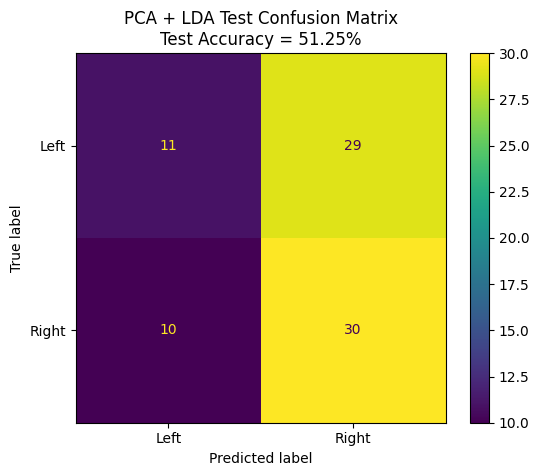


=== TVLDA ===
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Train file : P1_pre_training.mat
Test file  : P1_pre_test.mat
-----------------------------------
Training Accuracy        : 97.50%
Cross-Val Accuracy       : 91.25% ± 6.37%
Unseen Test Accuracy     : 91.25%


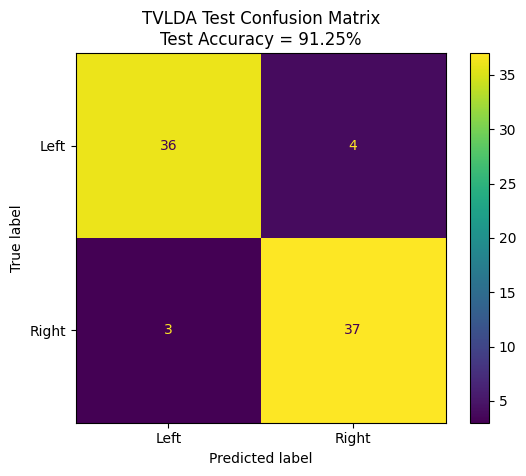


=== PCA + TVLDA ===
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Train file : P1_pre_training.mat
Test file  : P1_pre_test.mat
-----------------------------------
Training Accuracy        : 98.75%
Cross-Val Accuracy       : 93.75% ± 5.59%
Unseen Test Accuracy     : 91.25%


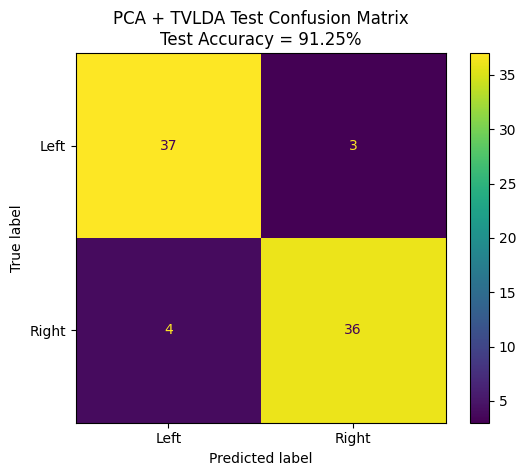

In [10]:
# =========================
# 5. RUN P1 PRE: PCA + LDA
# =========================

p1_pre_train = os.path.join(DATA_DIR, "P1_pre_training.mat")
p1_pre_test  = os.path.join(DATA_DIR, "P1_pre_test.mat")

print("=== PCA + LDA ===")
p1_pre_pca_results = run_pca_lda_with_all_accuracies(
    train_file=p1_pre_train,
    test_file=p1_pre_test,
    tmin=2.0,
    tmax=7.0,
    use_zscore=True,
    cv_folds=5,
    plot_confusion=True,
    n_components=8
)

print("\n=== TVLDA ===")
p1_pre_tvlda_results = run_tvlda_with_all_accuracies(
    train_file=p1_pre_train,
    test_file=p1_pre_test,
    tmin=2.0,
    tmax=7.0,
    use_zscore=True,
    cv_folds=5,
    plot_confusion=True
)

print("\n=== PCA + TVLDA ===")
p1_pre_pca_tvlda_results = run_pca_tvlda_with_all_accuracies(
    train_file=p1_pre_train,
    test_file=p1_pre_test,
    tmin=2.0,
    tmax=7.0,
    use_zscore=True,
    cv_folds=5,
    plot_confusion=True,
    n_components=8
)

In [11]:
# =========================
# 6. RUN ALL PATIENTS: PCA + LDA and TVLDA
# =========================

patients = ["P1", "P2", "P3"]
sessions = ["pre", "post"]

all_pca_results = {}
all_tvlda_results = {}
all_pca_tvlda_results = {}

for patient in patients:
    all_pca_results[patient] = {}
    all_tvlda_results[patient] = {}
    all_pca_tvlda_results[patient] = {}

    for session in sessions:
        train_file = os.path.join(DATA_DIR, f"{patient}_{session}_training.mat")
        test_file  = os.path.join(DATA_DIR, f"{patient}_{session}_test.mat")

        try:
            pca_result = run_pca_lda_with_all_accuracies(
                train_file=train_file,
                test_file=test_file,
                tmin=2.0,
                tmax=7.0,
                use_zscore=True,
                cv_folds=5,
                plot_confusion=False,
                n_components=8
            )
            all_pca_results[patient][session] = pca_result
        except Exception as e:
            print(f"PCA failed for {patient} {session}: {type(e).__name__}: {e}")
            all_pca_results[patient][session] = {
                "train_accuracy": 0,
                "cv_accuracy_mean": 0,
                "cv_accuracy_std": 0,
                "test_accuracy": 0,
                "model": None
            }

        try:
            tvlda_result = run_tvlda_with_all_accuracies(
                train_file=train_file,
                test_file=test_file,
                tmin=2.0,
                tmax=7.0,
                use_zscore=True,
                cv_folds=5,
                plot_confusion=False
            )
            all_tvlda_results[patient][session] = tvlda_result
        except Exception as e:
            print(f"TVLDA failed for {patient} {session}: {type(e).__name__}: {e}")
            all_tvlda_results[patient][session] = {
                "train_accuracy": 0,
                "cv_accuracy_mean": 0,
                "cv_accuracy_std": 0,
                "test_accuracy": 0,
                "model": None
            }

        try:
            pca_tvlda_result = run_pca_tvlda_with_all_accuracies(
                train_file=train_file,
                test_file=test_file,
                tmin=2.0,
                tmax=7.0,
                use_zscore=True,
                cv_folds=5,
                plot_confusion=False,
                n_components=8
            )
            all_pca_tvlda_results[patient][session] = pca_tvlda_result
        except Exception as e:
            print(f"PCA+TVLDA failed for {patient} {session}: {type(e).__name__}: {e}")
            all_pca_tvlda_results[patient][session] = {
                "train_accuracy": 0,
                "cv_accuracy_mean": 0,
                "cv_accuracy_std": 0,
                "test_accuracy": 0,
                "model": None
            }

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Train file : P1_pre_training.mat
Test file  : P1_pre_test.mat
-----------------------------------
Training Accuracy        : 56.25%
Cross-Val Accuracy       : 41.25% ± 8.48%
Unseen Test Accuracy     : 51.25%
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Train file : P1_pre_training.mat
Test file  : P1_pre_test.mat
-----------------------------------
Training Accuracy        : 97.50%
Cross-Val Accuracy       : 91.25% ± 6.37%
Unseen Test Accuracy     : 91.25%
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
EEG channel type selected for

In [12]:
# =========================
# 7. FINAL SUMMARY TABLES
# =========================

print("\n================ PCA + LDA SUMMARY ================")
print("Patient | Session | Train Acc | CV Acc        | Test Acc")
print("------------------------------------------------")

for patient in patients:
    for session in sessions:
        r = all_pca_results[patient][session]

        print(
            f"{patient:7s} | "
            f"{session.upper():7s} | "
            f"{r['train_accuracy']:8.2f}% | "
            f"{r['cv_accuracy_mean']:6.2f}% ± {r['cv_accuracy_std']:.2f}% | "
            f"{r['test_accuracy']:8.2f}%"
        )

print("====================================================")

print("\n================ TVLDA SUMMARY ================")
print("Patient | Session | Train Acc | CV Acc        | Test Acc")
print("------------------------------------------------")

for patient in patients:
    for session in sessions:
        r = all_tvlda_results[patient][session]

        print(
            f"{patient:7s} | "
            f"{session.upper():7s} | "
            f"{r['train_accuracy']:8.2f}% | "
            f"{r['cv_accuracy_mean']:6.2f}% ± {r['cv_accuracy_std']:.2f}% | "
            f"{r['test_accuracy']:8.2f}%"
        )

print("================================================")

print("\n================ PCA + TVLDA SUMMARY ================")
print("Patient | Session | Train Acc | CV Acc        | Test Acc")
print("------------------------------------------------")

for patient in patients:
    for session in sessions:
        r = all_pca_tvlda_results[patient][session]

        print(
            f"{patient:7s} | "
            f"{session.upper():7s} | "
            f"{r['train_accuracy']:8.2f}% | "
            f"{r['cv_accuracy_mean']:6.2f}% ± {r['cv_accuracy_std']:.2f}% | "
            f"{r['test_accuracy']:8.2f}%"
        )

print("====================================================")


================ PCA + LDA SUMMARY ================
Patient | Session | Train Acc | CV Acc        | Test Acc
------------------------------------------------
P1      | PRE     |    56.25% |  41.25% ± 8.48% |    51.25%
P1      | POST    |    71.25% |  62.50% ± 17.68% |    51.25%
P2      | PRE     |    62.50% |  48.75% ± 16.01% |    48.75%
P2      | POST    |    61.25% |  55.00% ± 7.29% |    47.50%
P3      | PRE     |    56.25% |  53.75% ± 8.48% |    57.50%
P3      | POST    |    62.50% |  50.00% ± 7.91% |    48.75%

================ TVLDA SUMMARY ================
Patient | Session | Train Acc | CV Acc        | Test Acc
------------------------------------------------
P1      | PRE     |    97.50% |  91.25% ± 6.37% |    91.25%
P1      | POST    |    98.75% |  95.00% ± 4.68% |    88.75%
P2      | PRE     |    86.25% |  76.25% ± 12.12% |    71.25%
P2      | POST    |    93.75% |  76.25% ± 9.19% |    88.75%
P3      | PRE     |   100.00% |  95.00% ± 4.68% |    86.25%
P3      | POST    |    